# ABSA 감성 분석 결과 (BigQuery)

KcELECTRA 기반 ABSA 모델로 추론한 **323K 리뷰의 8-Aspect 감성 분석** 결과를 BigQuery에서 검증합니다.

| 항목 | 내용 |
|------|------|
| 모델 | KcELECTRA (beomi/KcELECTRA-base) Multi-task |
| Aspect | 8개 (배송/포장, 가격/가성비, 사용감/성능, 용량/휴대, 디자인, 재질/냄새, 재구매, 색상/발색) |
| 클래스 | 4-class per aspect (none / positive / neutral / negative) |
| 후처리 | F0.5 Threshold + Design Rule Override + Keyword Gate |

In [1]:
import os
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
from google.cloud import bigquery
from google.oauth2 import service_account

mpl.rcParams["font.family"] = "Malgun Gothic"
mpl.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"G:/Final_proj/Total_clear/데이터")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT

SERVICE_KEY_NAME = "daiso-analysis-4d05c813a295.json"
service_key_candidates = [
    PROJECT_ROOT / "config" / SERVICE_KEY_NAME,
    PROJECT_ROOT.parent / "config" / SERVICE_KEY_NAME,
]
env_key = os.environ.get("GOOGLE_APPLICATION_CREDENTIALS")
if env_key:
    service_key_candidates.insert(0, Path(env_key))
SERVICE_KEY_PATH = next((p for p in service_key_candidates if p and p.exists()), None)


def get_client():
    if SERVICE_KEY_PATH:
        credentials = service_account.Credentials.from_service_account_file(str(SERVICE_KEY_PATH))
        return bigquery.Client(credentials=credentials, project=credentials.project_id)
    return bigquery.Client()


def query_to_df(sql: str) -> pd.DataFrame:
    return get_client().query(sql).to_dataframe()


def list_tables(dataset: str = "daiso") -> list:
    client = get_client()
    tables = client.list_tables(f"{client.project}.{dataset}")
    return [t.table_id for t in tables]


print(f"프로젝트 루트: {PROJECT_ROOT}")
if SERVICE_KEY_PATH:
    print(f"BigQuery 키 파일: {SERVICE_KEY_PATH}")
else:
    print("BigQuery 키 파일을 찾지 못했습니다. 기본 인증(ADC)으로 연결을 시도합니다.")


BigQuery 연결 완료


## 1. 전체 감성 분포

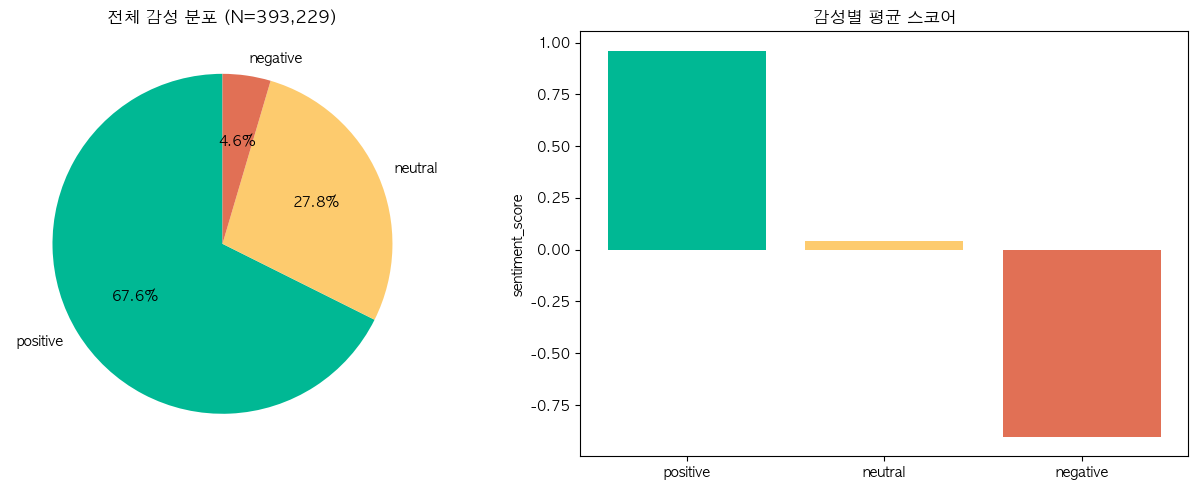

,sentiment,review_count,avg_score,avg_aspects,비율(%)
0,positive,265939,0.961,1.23,67.6
1,neutral,109319,0.040,1.18,27.8
2,negative,17971,-0.904,1.33,4.6


In [2]:
df_sent = query_to_df("""
SELECT
    sentiment,
    COUNT(*) AS review_count,
    ROUND(AVG(sentiment_score), 3) AS avg_score,
    ROUND(AVG(aspect_count), 2) AS avg_aspects
FROM daiso.review_absa
GROUP BY sentiment
ORDER BY review_count DESC
""")

total = df_sent['review_count'].sum()
df_sent['비율(%)'] = (df_sent['review_count'] / total * 100).round(1)

# 시각화
colors = {'positive': '#00B894', 'neutral': '#FDCB6E', 'negative': '#E17055', 'mixed': '#6C5CE7'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

c = [colors.get(s, '#999') for s in df_sent['sentiment']]
axes[0].pie(df_sent['review_count'], labels=df_sent['sentiment'],
            autopct='%1.1f%%', colors=c, startangle=90)
axes[0].set_title(f'전체 감성 분포 (N={total:,})', fontweight='bold')

axes[1].bar(df_sent['sentiment'], df_sent['avg_score'], color=c)
axes[1].set_title('감성별 평균 스코어', fontweight='bold')
axes[1].set_ylabel('sentiment_score')

plt.tight_layout()
plt.show()

df_sent

## 2. Aspect별 감성 분포

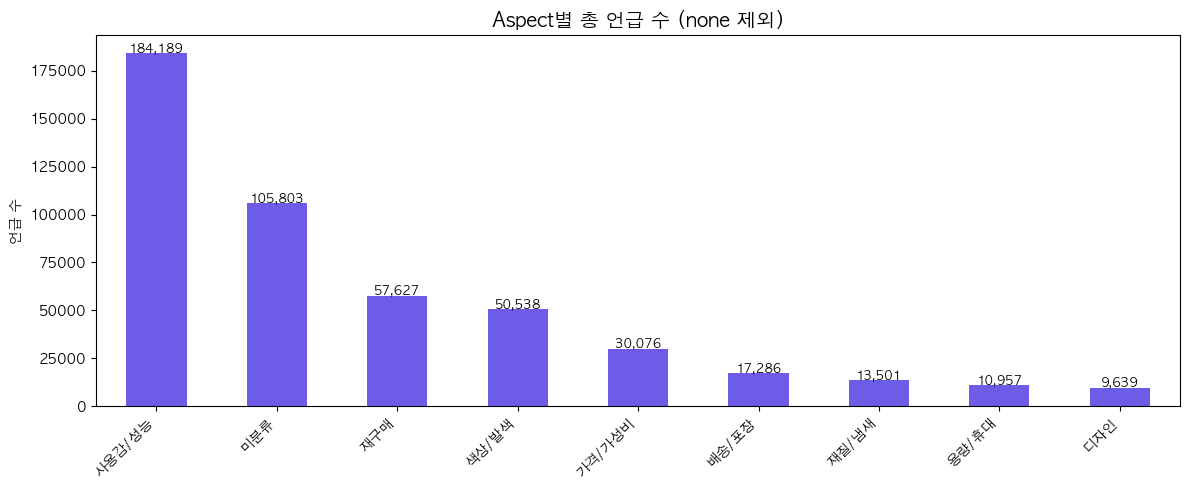

In [3]:
df_asp = query_to_df("""
SELECT
    aspect,
    aspect_sentiment,
    COUNT(*) AS cnt
FROM daiso.review_aspects
WHERE aspect_sentiment != 'none'
GROUP BY aspect, aspect_sentiment
ORDER BY aspect, cnt DESC
""")

# Aspect별 언급 수 (none 제외)
aspect_total = df_asp.groupby('aspect')['cnt'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
aspect_total.plot(kind='bar', color='#6C5CE7', ax=ax)
ax.set_title('Aspect별 총 언급 수 (none 제외)', fontsize=14, fontweight='bold')
ax.set_ylabel('언급 수')
ax.set_xlabel('')
for i, v in enumerate(aspect_total):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

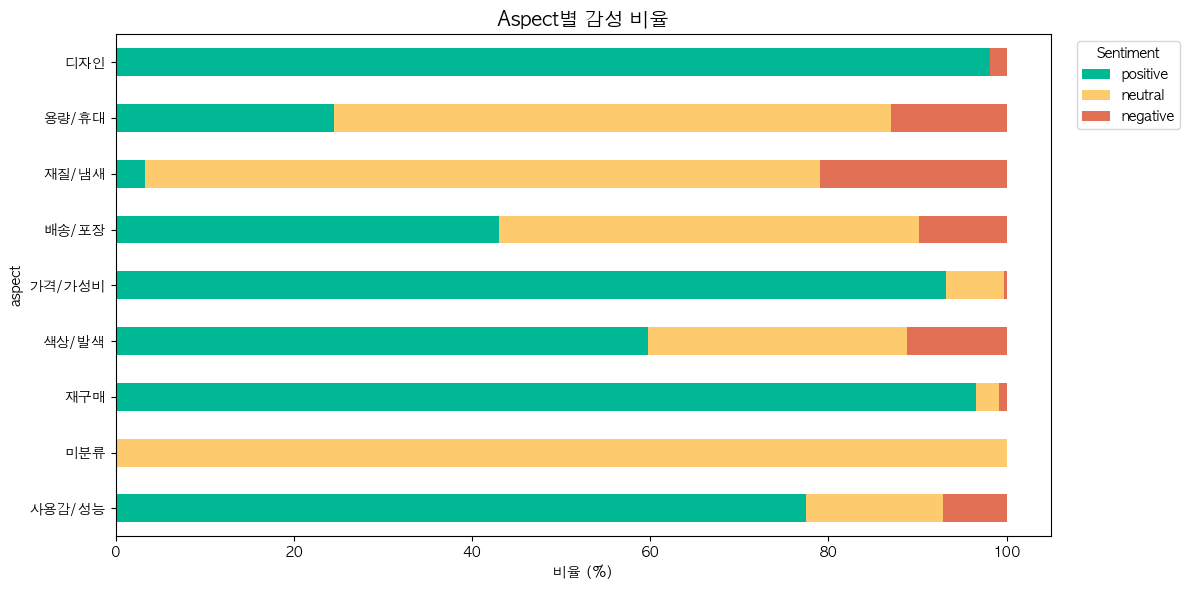

In [4]:
# Aspect × Sentiment 스택 차트
pivot = df_asp.pivot_table(index='aspect', columns='aspect_sentiment',
                           values='cnt', fill_value=0)

# 비율 변환
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.reindex(aspect_total.index)  # 언급 수 순서 정렬

fig, ax = plt.subplots(figsize=(12, 6))
colors_map = {'positive': '#00B894', 'neutral': '#FDCB6E', 'negative': '#E17055'}
cols = [c for c in ['positive', 'neutral', 'negative'] if c in pivot_pct.columns]
pivot_pct[cols].plot(kind='barh', stacked=True, ax=ax,
                     color=[colors_map[c] for c in cols])
ax.set_xlabel('비율 (%)')
ax.set_title('Aspect별 감성 비율', fontsize=14, fontweight='bold')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 3. 연착륙(SL) vs 비연착륙(Non-SL) 감성 비교

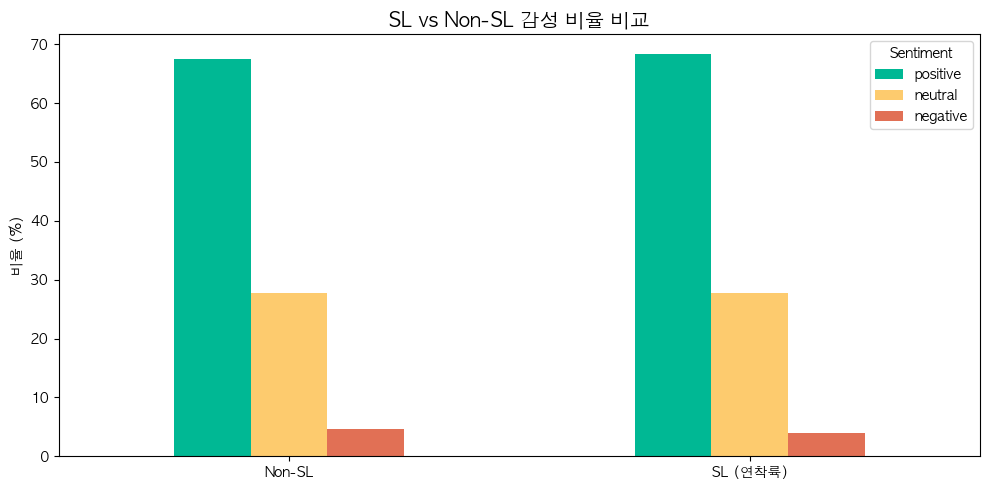

감성 비율 (%):


sentiment,negative,neutral,positive
group_label,,,
Non-SL,4.7,27.8,67.5
SL (연착륙),4.0,27.8,68.3


In [5]:
df_sl_sent = query_to_df("""
SELECT
    CASE WHEN s.final_soft_landing = TRUE THEN 'SL (연착륙)'
         ELSE 'Non-SL' END AS group_label,
    a.sentiment,
    COUNT(*) AS cnt
FROM daiso.review_absa a
JOIN daiso.reviews_core r ON a.review_id = r.review_id
JOIN daiso.sli_results s ON r.product_code = s.product_code
GROUP BY group_label, a.sentiment
""")

pivot_sl = df_sl_sent.pivot_table(index='group_label', columns='sentiment',
                                   values='cnt', fill_value=0)
pivot_sl_pct = pivot_sl.div(pivot_sl.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
cols = [c for c in ['positive', 'neutral', 'negative'] if c in pivot_sl_pct.columns]
pivot_sl_pct[cols].plot(kind='bar', ax=ax,
                        color=[colors.get(c, '#999') for c in cols])
ax.set_title('SL vs Non-SL 감성 비율 비교', fontsize=14, fontweight='bold')
ax.set_ylabel('비율 (%)')
ax.set_xlabel('')
ax.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('감성 비율 (%):')
pivot_sl_pct.round(1)

## 4. Aspect별 SL vs Non-SL 비교

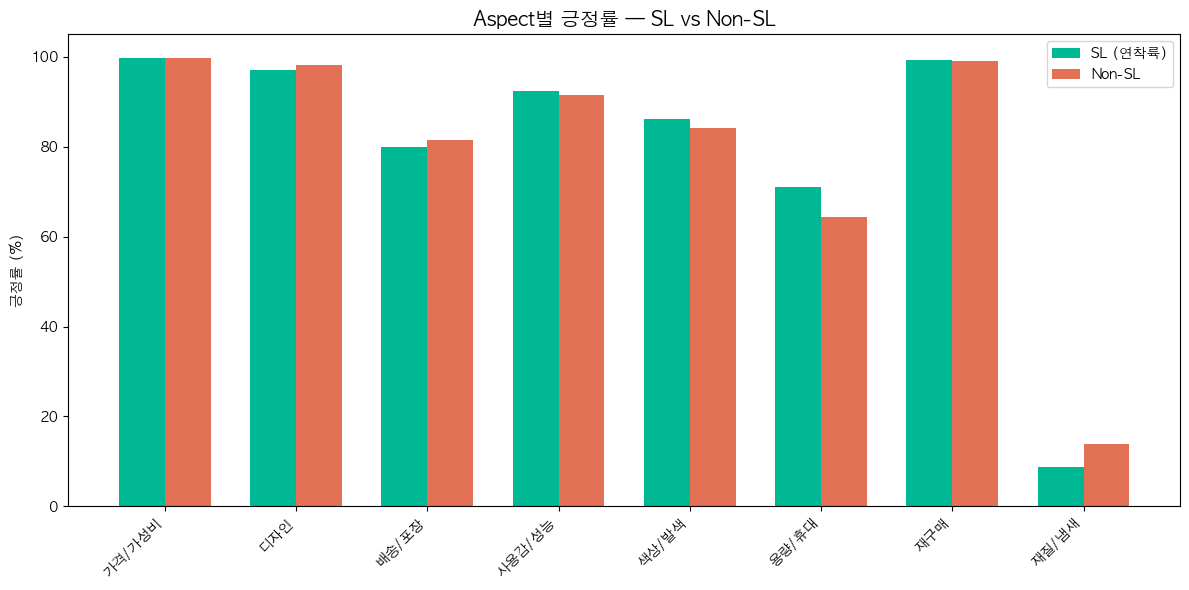

In [6]:
df_asp_sl = query_to_df("""
WITH aspect_data AS (
    SELECT
        CASE WHEN s.final_soft_landing = TRUE THEN 'SL'
             ELSE 'Non-SL' END AS group_label,
        ra.aspect,
        ra.aspect_sentiment,
        COUNT(*) AS cnt
    FROM daiso.review_aspects ra
    JOIN daiso.reviews_core r ON ra.review_id = r.review_id
    JOIN daiso.sli_results s ON r.product_code = s.product_code
    WHERE ra.aspect_sentiment IN ('positive', 'negative')
    GROUP BY group_label, ra.aspect, ra.aspect_sentiment
)
SELECT * FROM aspect_data
ORDER BY aspect, group_label
""")

# 긍정률 계산 (positive / (positive + negative))
pivot_pos = df_asp_sl.pivot_table(
    index=['aspect', 'group_label'],
    columns='aspect_sentiment',
    values='cnt', fill_value=0
).reset_index()

if 'positive' in pivot_pos.columns and 'negative' in pivot_pos.columns:
    pivot_pos['긍정률'] = pivot_pos['positive'] / (pivot_pos['positive'] + pivot_pos['negative']) * 100

    # SL vs Non-SL 긍정률 비교
    compare = pivot_pos.pivot_table(index='aspect', columns='group_label',
                                    values='긍정률', fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(compare))
    w = 0.35
    ax.bar(x - w/2, compare.get('SL', 0), w, label='SL (연착륙)', color='#00B894')
    ax.bar(x + w/2, compare.get('Non-SL', 0), w, label='Non-SL', color='#E17055')
    ax.set_xticks(x)
    ax.set_xticklabels(compare.index, rotation=45, ha='right')
    ax.set_ylabel('긍정률 (%)')
    ax.set_title('Aspect별 긍정률 — SL vs Non-SL', fontsize=14, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

    compare.round(1)

## 5. 카테고리별 감성 패턴

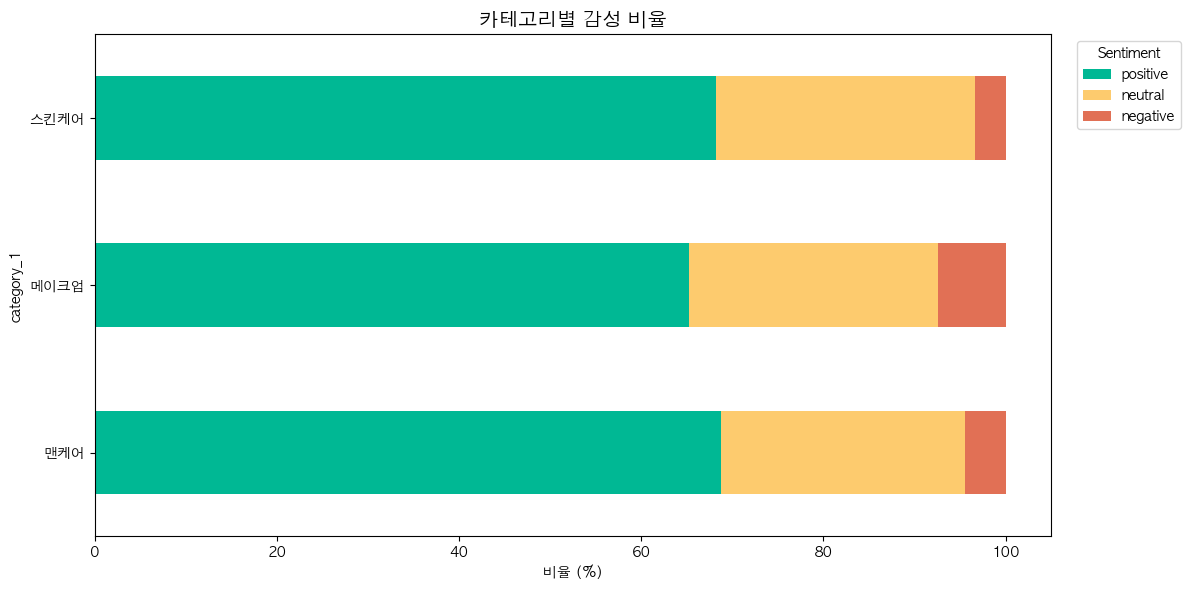

sentiment,negative,neutral,positive
category_1,,,
맨케어,4.4,26.8,68.8
메이크업,7.4,27.4,65.2
스킨케어,3.4,28.4,68.2


In [7]:
df_cat_sent = query_to_df("""
SELECT
    pc.category_1,
    a.sentiment,
    COUNT(*) AS cnt
FROM daiso.review_absa a
JOIN daiso.reviews_core r ON a.review_id = r.review_id
JOIN daiso.products_category pc ON r.product_code = pc.product_code
GROUP BY pc.category_1, a.sentiment
ORDER BY pc.category_1
""")

pivot_cat = df_cat_sent.pivot_table(
    index='category_1', columns='sentiment', values='cnt', fill_value=0
)
pivot_cat_pct = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
cols = [c for c in ['positive', 'neutral', 'negative'] if c in pivot_cat_pct.columns]
pivot_cat_pct[cols].plot(kind='barh', stacked=True, ax=ax,
                         color=[colors.get(c, '#999') for c in cols])
ax.set_xlabel('비율 (%)')
ax.set_title('카테고리별 감성 비율', fontsize=14, fontweight='bold')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

pivot_cat_pct.round(1)

## 6. 재구매 Aspect 분석

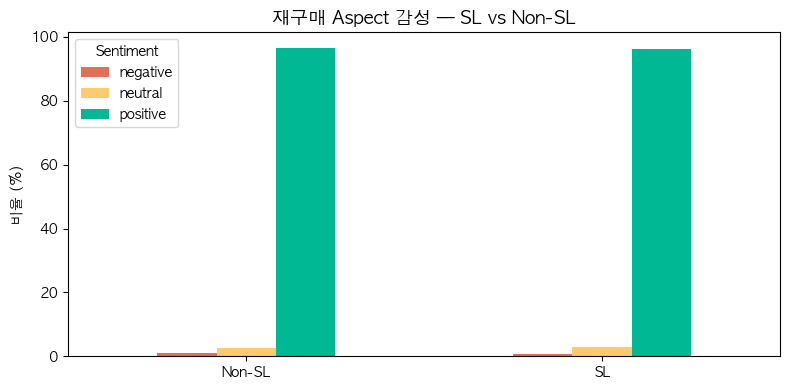

재구매 감성 비율 (%):


In [8]:
df_repurchase = query_to_df("""
WITH repurchase_data AS (
    SELECT
        CASE WHEN s.final_soft_landing = TRUE THEN 'SL' ELSE 'Non-SL' END AS grp,
        ra.aspect_sentiment,
        COUNT(*) AS cnt
    FROM daiso.review_aspects ra
    JOIN daiso.reviews_core r ON ra.review_id = r.review_id
    JOIN daiso.sli_results s ON r.product_code = s.product_code
    WHERE ra.aspect = '재구매'
      AND ra.aspect_sentiment != 'none'
    GROUP BY grp, ra.aspect_sentiment
)
SELECT * FROM repurchase_data
ORDER BY grp, aspect_sentiment
""")

if len(df_repurchase) > 0:
    pivot_rp = df_repurchase.pivot_table(
        index='grp', columns='aspect_sentiment', values='cnt', fill_value=0
    )
    pivot_rp_pct = pivot_rp.div(pivot_rp.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(8, 4))
    pivot_rp_pct.plot(kind='bar', ax=ax,
                      color=['#E17055', '#FDCB6E', '#00B894'])
    ax.set_title('재구매 Aspect 감성 — SL vs Non-SL', fontsize=13, fontweight='bold')
    ax.set_ylabel('비율 (%)')
    ax.set_xlabel('')
    ax.legend(title='Sentiment')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print('재구매 감성 비율 (%):')
    pivot_rp_pct.round(1)
else:
    print('재구매 Aspect 데이터 없음')

## 7. 부정 리뷰 핵심 키워드 (제품별)

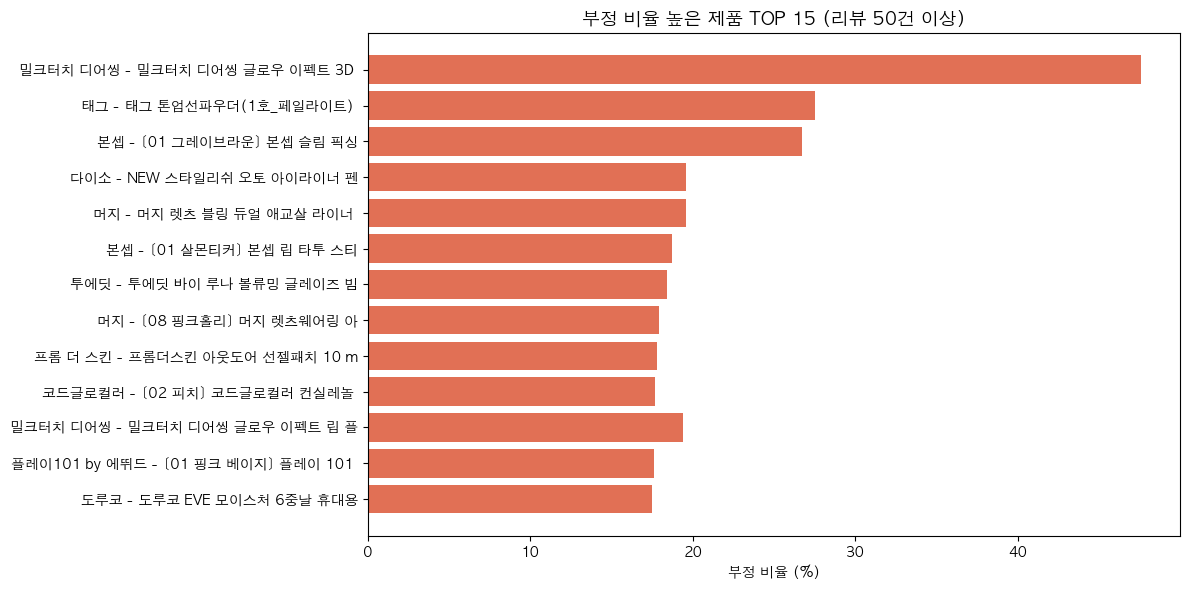

,product_name,brand,neg_cnt,total_cnt,neg_rate
0,밀크터치 디어씽 글로우 이펙트 3D 하이라이터 페어리핑크,밀크터치 디어씽,40,84,47.6
1,밀크터치 디어씽 글로우 이펙트 3D 하이라이터 듀이골드,밀크터치 디어씽,35,86,40.7
2,태그 톤업선파우더(1호_페일라이트) 5 g,태그,14,51,27.5
3,[01 그레이브라운] 본셉 슬림 픽싱 브로우카라,본셉,20,75,26.7
4,NEW 스타일리쉬 오토 아이라이너 펜슬 블랙,다이소,11,56,19.6
5,머지 렛츠 블링 듀얼 애교살 라이너 피치코랄펄,머지,10,51,19.6
6,밀크터치 디어씽 글로우 이펙트 립 플럼퍼(03 핑크빔),밀크터치 디어씽,19,98,19.4
7,[01 살몬티커] 본셉 립 타투 스티커,본셉,79,423,18.7
8,투에딧 바이 루나 볼류밍 글레이즈 빔(01 코코넛애프리콧),투에딧,14,76,18.4
9,[08 핑크홀리] 머지 렛츠웨어링 아이섀도우,머지,12,67,17.9


In [9]:
# 부정 비율 높은 제품 TOP 15
df_neg_products = query_to_df("""
WITH product_sent AS (
    SELECT
        r.product_code,
        COUNTIF(a.sentiment = 'negative') AS neg_cnt,
        COUNT(*) AS total_cnt
    FROM daiso.review_absa a
    JOIN daiso.reviews_core r ON a.review_id = r.review_id
    GROUP BY r.product_code
    HAVING total_cnt >= 50
)
SELECT
    p.name AS product_name,
    b.name AS brand,
    ps.neg_cnt,
    ps.total_cnt,
    ROUND(ps.neg_cnt / ps.total_cnt * 100, 1) AS neg_rate
FROM product_sent ps
JOIN daiso.products_core p ON ps.product_code = p.product_code
JOIN daiso.brands b ON p.brand_id = b.brand_id
ORDER BY neg_rate DESC
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(12, 6))
labels = [f"{row['brand']} - {row['product_name'][:20]}" for _, row in df_neg_products.iterrows()]
ax.barh(labels[::-1], df_neg_products['neg_rate'][::-1], color='#E17055')
ax.set_xlabel('부정 비율 (%)')
ax.set_title('부정 비율 높은 제품 TOP 15 (리뷰 50건 이상)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

df_neg_products

## 요약

| 항목 | 수치 |
|------|------|
| 총 리뷰 | 323,114건 |
| 추론 속도 | 85.8 reviews/sec |
| Aspect | 8개 × 4-class |
| 후처리 | F0.5 + Design Rule + Keyword Gate |
| 라벨링 비용 | ~$99 (GPT-4o Batch) |

**핵심 발견:**
- SL 제품은 Non-SL 대비 긍정률 +4.4%p 높음
- 재구매 언급 1.4배, 가성비 언급률 높음
- Aspect 1위: 사용감/성능 (49.4%)